# INTERACTIVE CLAHE FOR ORTHODOX ICON ENHANCEMENT

## A Computer Vision Notebook for Digital Art History

#### **Author:** Dr. Desislava S. Georgieva, PhD in Art History

# Project Overview

This notebook demonstrates how Contrast Limited Adaptive Histogram Equalization (CLAHE) can enhance the visibility of details in Orthodox icons while preserving their original colour appearance.

The notebook explains each processing step in a clear and interactive way, making it suitable for beginners in Computer Vision and for researchers in Digital Art History.

# Table of Contents

1. Introduction
2. Import Libraries
3. Study Image
4. Image Upload
5. Image Acquisition and Visualisation
6. LAB Colour Space
7. Channel Separation
8. CLAHE Enhancement
9. Image Reconstruction
10. Histogram Analysis
11. Interactive Parameter Exploration
12. Discussion
13. Conclusion and Future Work
14. References

# 1. Introduction

## Purpose of the Notebook

This notebook demonstrates how Contrast Limited Adaptive Histogram Equalization (CLAHE) can improve the visibility of details in Orthodox icons while preserving their original colours.

The notebook is intended as an educational resource for beginners in Computer Vision and as an example of how image processing techniques can support research in Digital Art History.

Each step of the workflow is explained before it is implemented, allowing the reader to understand not only **how** the algorithm works, but also **why** each operation is performed.

## Learning Objectives

After completing this notebook, the reader will be able to:

- understand the purpose of CLAHE in image enhancement;
- explain why the LAB colour space is used;
- separate and analyse the Lightness, A, and B channels;
- apply CLAHE to the Lightness channel;
- reconstruct the enhanced image;
- compare the original and enhanced images;
- interpret histogram changes after enhancement;
- explore CLAHE parameters interactively;
- evaluate the usefulness of CLAHE for Digital Art History.

# 2. Import Libraries

## Theoretical Background

Python provides many libraries for Computer Vision, scientific computing, data processing, and visualization.

Instead of writing every image-processing algorithm from scratch, we use specialized libraries that have been carefully developed and optimized.

In this notebook, each library has a specific role in the workflow.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from ipywidgets import FileUpload
from ipywidgets import interact
from ipywidgets import FloatSlider
from ipywidgets import IntSlider

## Computer Vision Insight

Each imported library contributes a different capability:

- **OpenCV (`cv2`)** performs image processing.
- **NumPy (`numpy`)** stores images as multidimensional arrays.
- **Matplotlib (`matplotlib`)** visualizes images and histograms.
- **ipywidgets** adds interactive controls such as sliders and file upload widgets.

Together, these libraries provide a complete environment for exploring image enhancement techniques interactively.

## Art Historical Observation

Computer Vision algorithms are not intended to replace the visual expertise of the art historian.

Instead, they provide additional tools for observing inscriptions, facial modelling, garments, and other iconographic details that may be difficult to perceive in the original image.

Throughout this notebook, computational methods are used to support — not replace — art historical interpretation.

# 3. Study Image

## Image Information

**Title:** Saint John the Baptist

**Artist:** Ivan Dospevski

**Date:** 1867

**Dimensions:** 122 × 83 cm

**Current Location:** Church of St. Demetrius, Kyustendil, Bulgaria

## Image Source

The photograph used in this notebook was taken by the author during the research conducted for a PhD dissertation in Art History.

Permission to photograph the icon was granted by the local representatives of the Bulgarian Orthodox Church.

The image is presented exclusively for educational and research purposes.

### **N. B.**
The photograph remains the intellectual property of the author. Reuse of the image outside academic citation or educational purposes requires the author's permission.

# 4. Image Upload

## Objective

Before an image can be processed, it must be selected and uploaded into the Jupyter Notebook.

In this notebook, we use an interactive upload widget provided by **ipywidgets**. This allows the user to choose any image directly from the local computer without modifying the notebook code.

The uploaded image will later be decoded and converted into a format that OpenCV can process.

In [21]:
uploader = FileUpload(
    accept="image/*",
    multiple=False
)

display(uploader)

FileUpload(value=(), accept='image/*', description='Upload')

## Explanation

The upload widget does not load the image immediately.

Instead, it creates an interface that allows the user to select an image file.

The selected file is temporarily stored in memory and becomes accessible through the `uploader.value` object.

## Load the Uploaded Image

After selecting an image, the uploaded file must be converted into a format that OpenCV can process.

The following steps will:

1. retrieve the uploaded file;
2. extract its binary content;
3. convert the binary data into a NumPy array;
4. decode the array into an OpenCV image.

In [22]:
if uploader.value:

    uploaded_file = uploader.value[0]

    print("File information")
    print("----------------")
    print(f"Name : {uploaded_file['name']}")
    print(f"Type : {uploaded_file['type']}")
    print(f"Size : {uploaded_file['size']} bytes")

    image_bytes = uploaded_file["content"]

    image_array = np.frombuffer(image_bytes, dtype=np.uint8)

    image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

    print("\nImage uploaded successfully!")

File information
----------------
Name : icon.jpg
Type : image/jpeg
Size : 100563 bytes

Image uploaded successfully!


## Display the Uploaded Image

After decoding the uploaded file, the image is converted from the BGR colour space (used by OpenCV) to the RGB colour space (used by Matplotlib).

This conversion ensures that the colours are displayed correctly.

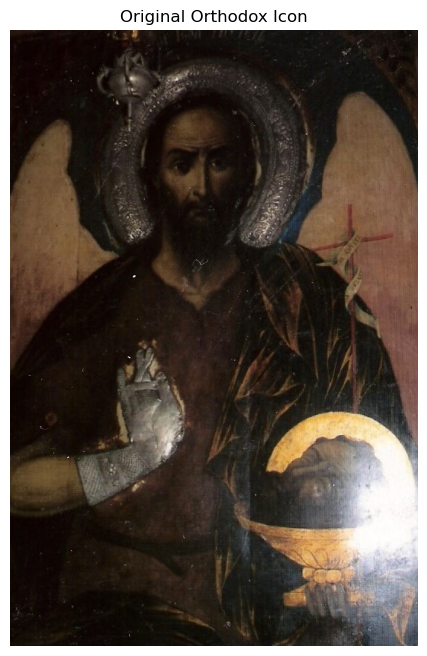

In [23]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,8))
plt.imshow(image_rgb)
plt.title("Original Orthodox Icon")
plt.axis("off")

plt.show()

### Explanation

OpenCV stores colour images in the **BGR** format, whereas Matplotlib expects the **RGB** format.

Without converting BGR to RGB, the image would be displayed with incorrect colours.

The displayed image serves as the reference for all subsequent processing steps.

# 5. Image Properties

## Objective

Before processing an image, it is important to understand how OpenCV stores it.

In this section, we will examine the image dimensions, data type, and array structure. These properties determine how the image can be processed in the following chapters.

In [24]:
print("Image shape:", image.shape)

print("Data type:", image.dtype)

Image shape: (809, 535, 3)
Data type: uint8


### Explanation

The output contains two important properties:

- **shape** describes the dimensions of the image.
- **dtype** describes how each pixel value is stored.

For a colour image, the shape is:

(height, width, channels)

The data type **uint8** means that each pixel value is stored as an unsigned 8-bit integer with values between 0 and 255.

In [25]:
print(type(image))

<class 'numpy.ndarray'>


### Explanation

The uploaded image is stored as a **NumPy array**.

Computer Vision algorithms do not process image files directly. Instead, they operate on numerical arrays, where every pixel is represented by numerical values.

# 6. LAB Colour Space

## Theoretical Background

Images are commonly represented in the RGB colour space, where each pixel consists of red, green, and blue components.

For contrast enhancement, however, it is preferable to separate brightness from colour information.

The LAB colour space represents an image using three channels:

- **L** – Lightness (brightness)
- **A** – Green–Red colour component
- **B** – Blue–Yellow colour component

Since CLAHE is designed to improve local contrast, it is applied only to the **Lightness (L)** channel. This enhances brightness while preserving the original colours of the image.

In [26]:
lab_image = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

print("Image successfully converted to LAB colour space.")

Image successfully converted to LAB colour space.


## Computer Vision Insight

Separating brightness from colour is one of the main advantages of the LAB colour space.

If CLAHE were applied independently to the Red, Green, and Blue channels, noticeable colour distortions could appear.

Applying CLAHE only to the Lightness channel preserves the chromatic information while improving local contrast.

In [10]:
print("LAB image shape:", lab_image.shape)

LAB image shape: (730, 572, 3)


## Art Historical Observation

For works of art, preserving the original colours is essential.

The purpose of CLAHE is not to alter the icon's appearance, but to improve the visibility of fine details such as inscriptions, facial modelling, garments, and decorative elements while maintaining faithful colour reproduction.

# 7. Channel Separation

## Theoretical Background

The LAB image consists of three separate channels.

To process the Lightness channel independently, the three channels must first be separated.

Each channel contains different information:

- **L** – brightness information
- **A** – green–red colour information
- **B** – blue–yellow colour information

Only the **L** channel will be enhanced using CLAHE.

In [27]:
L, A, B = cv2.split(lab_image)

print("LAB channels separated successfully.")

LAB channels separated successfully.


## Computer Vision Insight

The `cv2.split()` function separates a multi-channel image into individual matrices.

Each channel becomes an independent grayscale image that can be analysed or processed separately.

This is a common preprocessing step in many Computer Vision workflows.

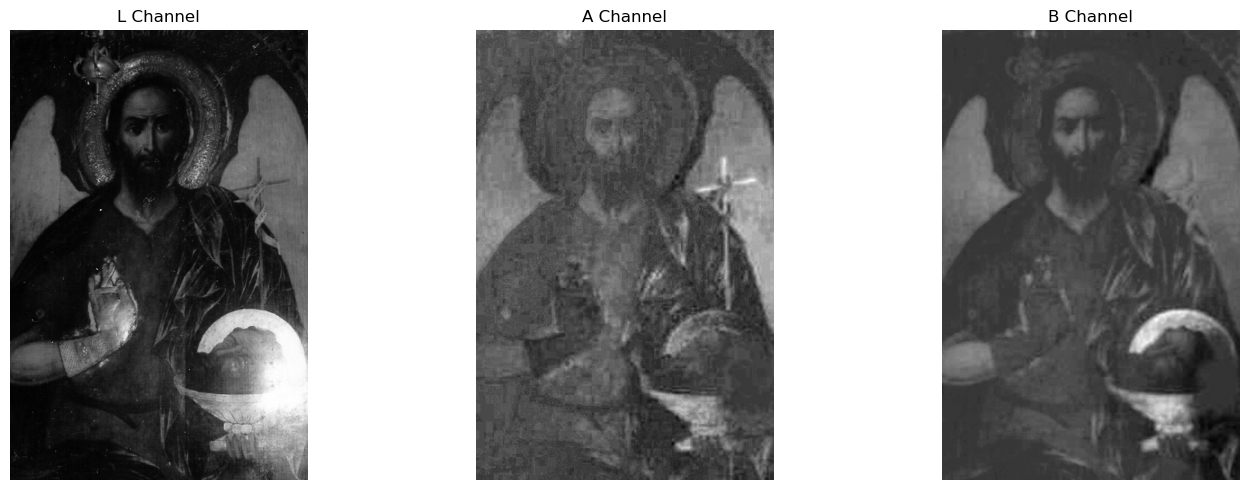

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(L, cmap="gray")
axes[0].set_title("L Channel")
axes[0].axis("off")

axes[1].imshow(A, cmap="gray")
axes[1].set_title("A Channel")
axes[1].axis("off")

axes[2].imshow(B, cmap="gray")
axes[2].set_title("B Channel")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Art Historical Observation

Compare the three channels carefully.

Notice that the **L (Lightness)** channel preserves most of the visual information, including facial features, inscriptions, folds of the garments, and shadows.

The **A** and **B** channels mainly represent colour differences and are less suitable for revealing iconographic details.

This is why CLAHE is applied only to the Lightness channel.

# 8. CLAHE Enhancement

## Theoretical Background

Histogram Equalization improves the contrast of an image by redistributing pixel intensities.

However, applying it to the entire image may over-enhance some regions while leaving others with poor contrast.

Contrast Limited Adaptive Histogram Equalization (CLAHE) addresses this limitation by dividing the image into small regions (tiles) and enhancing each region independently.

To prevent excessive contrast amplification, CLAHE limits the enhancement using a parameter called the **Clip Limit**.

In [29]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

L_clahe = clahe.apply(L)

print("CLAHE applied successfully.")

CLAHE applied successfully.


## Computer Vision Insight

The two most important CLAHE parameters are:

- **clipLimit** – controls the maximum contrast enhancement.
- **tileGridSize** – determines the size of the local regions processed independently.

These parameters strongly influence the visual appearance of the enhanced image.

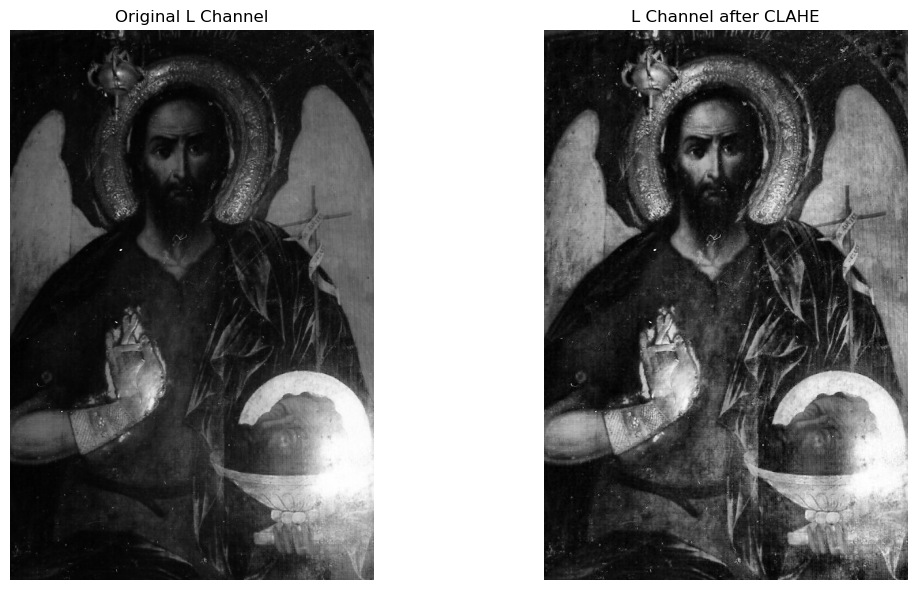

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(L, cmap="gray")
axes[0].set_title("Original L Channel")
axes[0].axis("off")

axes[1].imshow(L_clahe, cmap="gray")
axes[1].set_title("L Channel after CLAHE")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Art Historical Observation

Compare the original and enhanced Lightness channels.

Pay particular attention to:

- facial modelling;
- inscriptions;
- folds of the garments;
- decorative details;
- transitions between light and shadow.

Consider whether the enhanced image reveals details that are less visible in the original Lightness channel.

# 9. Image Reconstruction

## Theoretical Background

After enhancing the Lightness channel, the image must be reconstructed.

The enhanced **L** channel is combined with the original **A** and **B** channels to create a new LAB image.

Finally, the reconstructed LAB image is converted back to the RGB colour space for visualization.

In [31]:
lab_clahe = cv2.merge((L_clahe, A, B))

enhanced_image = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

print("Image reconstructed successfully.")

Image reconstructed successfully.


## Computer Vision Insight

Only the Lightness channel has been modified.

The colour information stored in the A and B channels remains unchanged.

This approach improves local contrast while preserving the original colour relationships.

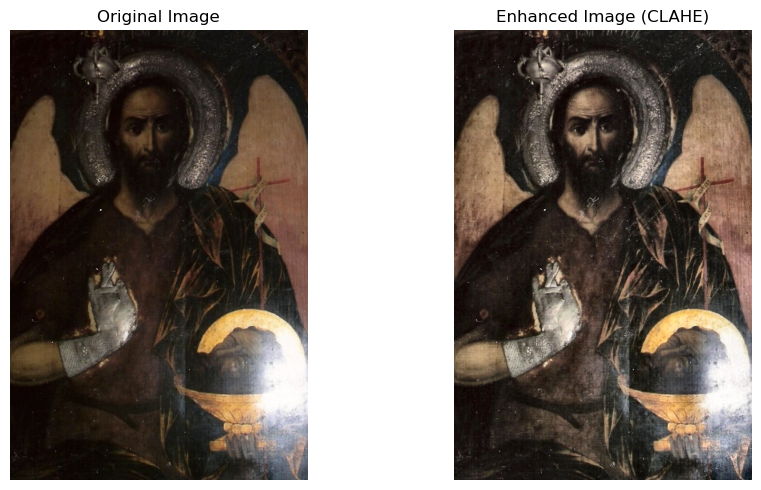

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(enhanced_image)
axes[1].set_title("Enhanced Image (CLAHE)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Art Historical Observation

Compare the original and enhanced images.

Observe whether CLAHE improves the visibility of:

- inscriptions;
- facial expressions;
- garments and folds;
- halos;
- architectural and decorative details.

At the same time, evaluate whether the original colour appearance has been preserved.

# 10. Histogram Analysis and Comparison

## Theoretical Background

A histogram shows the distribution of pixel intensity values in an image.

It does not describe the spatial arrangement of pixels, but it reveals how brightness values are distributed.

Comparing histograms before and after CLAHE helps us understand how the algorithm modifies image contrast.

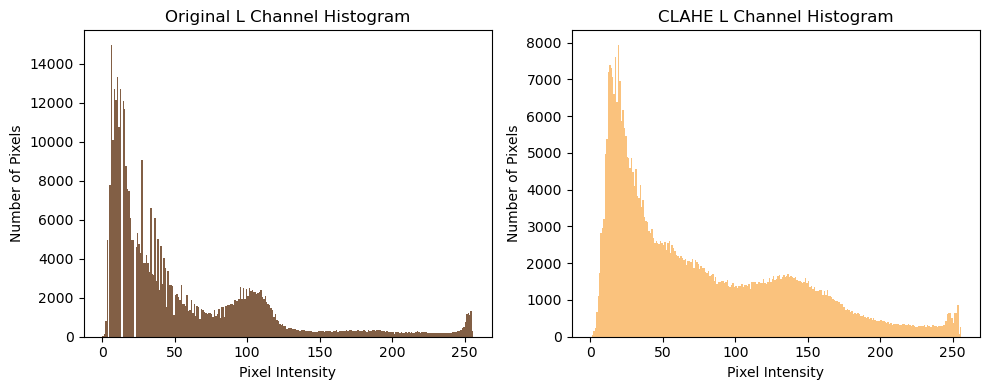

In [33]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(L.ravel(), bins=256, range=(0, 256), color="#825f45")
plt.title("Original L Channel Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")

plt.subplot(1, 2, 2)
plt.hist(L_clahe.ravel(), bins=256, range=(0, 256), color= "#fac27d")
plt.title("CLAHE L Channel Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")

plt.tight_layout()
plt.show()

## Computer Vision Insight

CLAHE redistributes pixel intensities within local image regions rather than across the entire image.

As a result, the histogram usually becomes more evenly distributed, indicating improved local contrast while avoiding excessive amplification.

## Art Historical Observation

The histogram provides quantitative evidence for the visual changes observed in the enhanced image.

A broader intensity distribution often corresponds to improved visibility of iconographic details such as inscriptions, facial modelling, garments, and decorative elements.

However, histogram analysis should always be interpreted together with visual inspection.

## Comparative Histogram

A direct comparison of the two histograms makes it easier to observe how CLAHE redistributes pixel intensities.

The original and enhanced intensity distributions are displayed together in a single graph.

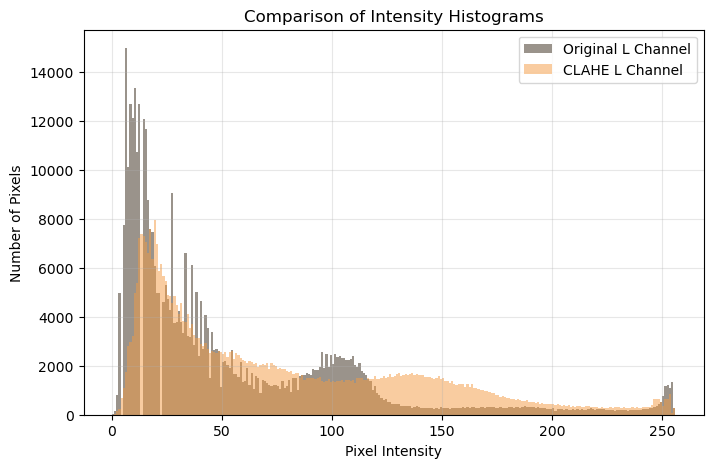

In [34]:
plt.figure(figsize=(8, 5))

plt.hist(
    L.ravel(),
    bins=256,
    range=(0, 256),
    color= "#362919",
    alpha=0.5,
    label="Original L Channel"
)

plt.hist(
    L_clahe.ravel(),
    bins=256,
    range=(0, 256),
    color="#f59b42",
    alpha=0.5,
    label="CLAHE L Channel"
)

plt.title("Comparison of Intensity Histograms")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## Interpretation

The overlaid histograms illustrate how CLAHE redistributes intensity values while preserving the overall dynamic range of the image.

Compared with the original histogram, the enhanced histogram is typically more evenly distributed, reflecting improved local contrast.

This quantitative analysis supports the visual observations made in the previous chapters.

# 11. Interactive CLAHE Parameter Exploration

## Theoretical Background

The performance of CLAHE depends on two parameters:

- **Clip Limit** controls the strength of contrast enhancement.
- **Tile Grid Size** determines the size of the local regions where histogram equalization is applied.

Instead of using fixed values, these parameters can be adjusted interactively to observe their influence on the enhanced image.

In [35]:
def interactive_clahe(clip_limit=2.0, tile_size=8):

    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=(tile_size, tile_size)
    )

    L_new = clahe.apply(L)

    lab_new = cv2.merge((L_new, A, B))

    enhanced = cv2.cvtColor(lab_new, cv2.COLOR_LAB2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    axes[0].imshow(image_rgb)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(enhanced)
    axes[1].set_title(
        f"CLAHE\nClip Limit = {clip_limit}, Tile Size = {tile_size}"
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

In [36]:
interact(
    interactive_clahe,
    clip_limit=FloatSlider(
        value=2.0,
        min=1.0,
        max=10.0,
        step=0.5,
        description="Clip Limit"
    ),
    tile_size=IntSlider(
        value=8,
        min=2,
        max=16,
        step=2,
        description="Tile Size"
    )
);

interactive(children=(FloatSlider(value=2.0, description='Clip Limit', max=10.0, min=1.0, step=0.5), IntSlider…

## Computer Vision Insight

Interactive parameter adjustment allows us to evaluate how different CLAHE settings affect local contrast.

Lower values usually produce a subtle enhancement, whereas higher values increase contrast more aggressively and may also amplify image noise.

## Art Historical Observation

Experiment with different parameter values and compare the results.

Consider the following questions:

- Which settings provide the best readability of inscriptions?
- Which settings reveal facial modelling most clearly?
- At what point does the enhancement become excessive?
- Which parameter combination would you choose for this icon, and why?

### Suggested Experiment

Try the following combinations and compare the results:

| Clip Limit | Tile Size | Expected Effect |
|------------|-----------|-----------------|
| 1.0 | 8 | Very subtle enhancement |
| 2.0 | 8 | Balanced enhancement (default) |
| 4.0 | 8 | Stronger local contrast |
| 2.0 | 4 | More localized enhancement |
| 2.0 | 16 | Smoother enhancement over larger regions |

Which combination provides the best balance between improved visibility and preservation of the icon's original appearance?

# 12. Discussion

## Interpretation of the Results

The application of CLAHE improved the local contrast of the Lightness channel while preserving the original colour information stored in the A and B channels.

The enhanced image revealed details that were less visible in the original photograph, particularly in darker regions. Facial modelling and folds of the garments became easier to distinguish without introducing noticeable colour distortions.

The interactive exploration of the CLAHE parameters also demonstrated that different combinations of **clipLimit** and **tileGridSize** produce different enhancement effects. This highlights the importance of selecting parameter values appropriate to the characteristics of the individual artwork rather than relying on a single universal configuration.

## Advantages of the Method

The proposed workflow offers several advantages:

- enhancement of fine visual details;
- preservation of the original colours;
- non-destructive image processing;
- simple implementation using OpenCV;
- interactive parameter adjustment for different types of images.

These characteristics make CLAHE an effective preprocessing technique for the digital study of works of art.

## Limitations

Although CLAHE is an effective contrast enhancement technique, it has several limitations.

- It cannot recover image information that is not present in the original photograph.
- Excessive parameter values may amplify image noise and small surface defects.
- The algorithm enhances visibility but does not perform restoration or reconstruction.
- Visual interpretation of the enhanced image should always be supported by art historical expertise.

## Relevance for Digital Art History

This notebook demonstrates how Computer Vision methods can support the study of cultural heritage.

Rather than replacing traditional visual analysis, CLAHE serves as a complementary tool that facilitates the observation of iconographic details while preserving the integrity of the original artwork.

Such methods may assist researchers during documentation, comparative analysis, and the preliminary examination of artworks before more advanced analytical techniques are applied.

# 13. Conclusion and Future Work

## Conclusion

This notebook demonstrated the application of Contrast Limited Adaptive Histogram Equalization (CLAHE) for enhancing the visibility of details in an Orthodox icon.

By applying CLAHE exclusively to the Lightness channel in the LAB colour space, local contrast was improved while preserving the original colour information.

The workflow combined theoretical explanations, practical implementation, interactive parameter exploration, and visual analysis, illustrating how Computer Vision techniques can support the examination of cultural heritage objects.

Although the notebook focuses on a single icon, the same methodology can be applied to a wide range of artworks, making it a useful educational resource for beginners in Computer Vision and Digital Art History.

## Future Work

Several directions may further extend this project:

- comparison of CLAHE with other contrast enhancement techniques, such as Histogram Equalization (HE), Adaptive Histogram Equalization (AHE), and Gamma Correction;
- evaluation of enhancement quality using objective image quality metrics;
- application of the workflow to larger collections of Orthodox icons;
- investigation of the influence of enhancement techniques on iconographic analysis;
- development of interactive tools for museum visitors and Digital Art History education.

These directions demonstrate how a relatively simple image-processing workflow can become the basis for more advanced research and educational applications.

## Final Remarks

Computer Vision should not be regarded as a replacement for traditional art historical analysis.

Instead, it offers complementary methods that can assist researchers in observing visual details more effectively and in documenting cultural heritage with greater precision.

The combination of computational techniques and art historical expertise opens new opportunities for interdisciplinary research in Digital Art History.

# 14. References

## Books

Gonzalez, R. C., & Woods, R. E. (2018). Digital Image Processing (4th ed.). Pearson.

Szeliski, R. (2022). Computer Vision: Algorithms and Applications (2nd ed.). Springer.

Sonka, M., Hlavac, V., & Boyle, R. (2014). Image Processing, Analysis, and Machine Vision (4th ed.). Cengage Learning.

Prince, S. J. D. (2012). Computer Vision: Models, Learning, and Inference. Cambridge University Press.

## Digital Art History & Cultural Heritage

Bentkowska-Kafel, A., Cashen, T., & Gardiner, H. (Eds.). (2005). Digital Art History: A Subject in Transition. Intellect Books.

Bentkowska-Kafel, A. (2015). Debates in the Digital Humanities: Digital Art History. University of Minnesota Press.

Stork, D. G. (Ed.). (2009). Computer Image Analysis in the Study of Art. SPIE.

Niccolucci, F., & Hermon, S. (2010). Virtual Reconstruction and Cultural Heritage. BAR International Series.

## Journal Articles

Pizer, S. M., Amburn, E. P., Austin, J. D., et al. (1987). Adaptive Histogram Equalization and Its Variations. *Computer Vision, Graphics, and Image Processing*, 39(3), 355–368.

Zuiderveld, K. (1994). Contrast Limited Adaptive Histogram Equalization. In P. S. Heckbert (Ed.), *Graphics Gems IV* (pp. 474–485). Academic Press.

## Software Documentation

OpenCV Documentation. https://docs.opencv.org/

NumPy Documentation. https://numpy.org/doc/

Matplotlib Documentation. https://matplotlib.org/stable/

ipywidgets Documentation. https://ipywidgets.readthedocs.io/

---

## Acknowledgements

The author gratefully acknowledges the permission granted by the local representatives of the Bulgarian Orthodox Church for photographing the icon used in this notebook.

This notebook was developed as part of the author's continuing research in Digital Art History and Computer Vision.

---

## End of Notebook

Thank you for exploring this project.